# 04b — Northern IPCAs results: connective corridors

Results for the northern_ipcas run (`config.ANALYSES["northern_ipcas"]`). The **NEW candidate areas** are the connective land the solve added between the anchors; the **benchmark** is the proposed IPCAs themselves (largest 6 star-plotted; all 13 shown on the maps in teal). Contribution/efficiency are shares of the **full Y2Y** totals. **Requires** `output_data/iter6_northern_ipcas/` (run 03b first). **Kernel:** `.venv`.

In [1]:
# ---- Setup: shared results engine + this analysis' key -------------------
import importlib
import results_core as rc, config
importlib.reload(config); importlib.reload(rc)

ANALYSIS = "northern_ipcas"       # <-- the ONLY line that differs between 04a / 04b / 04c
A = rc.load(ANALYSIS)          # locate the run + region label + map outline + benchmark spec
rc.load_rasters(A)             # portfolio + selection-frequency rasters

analysis=northern_ipcas | run=iter6_northern_ipcas | objective=min_shortfall | proportion/LP
region=Northern BC + Yukon | figures -> output_data/iter6_northern_ipcas/figures
portfolio: 1 solution(s) | grid 631 x 1351
allocation surface: 0.00..1.00


<results northern_ipcas | iter6_northern_ipcas | 631x1351>

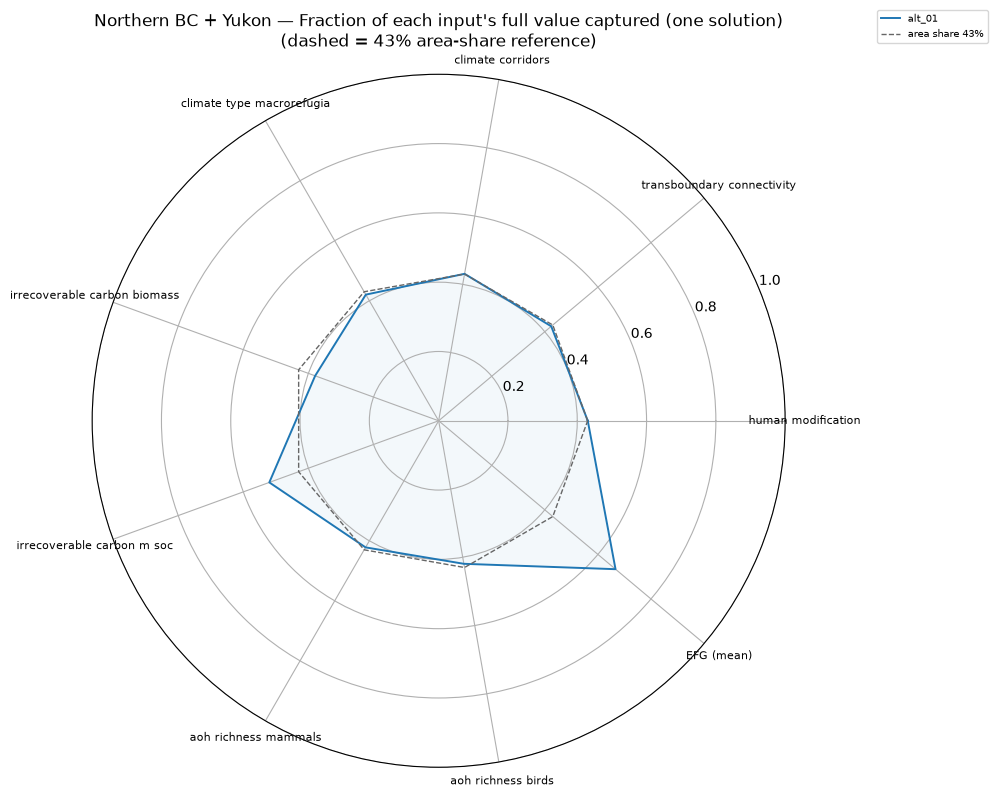

In [2]:
# ---- Radar: captured fraction per input vs the area-share ring ----
rc.radar(A)

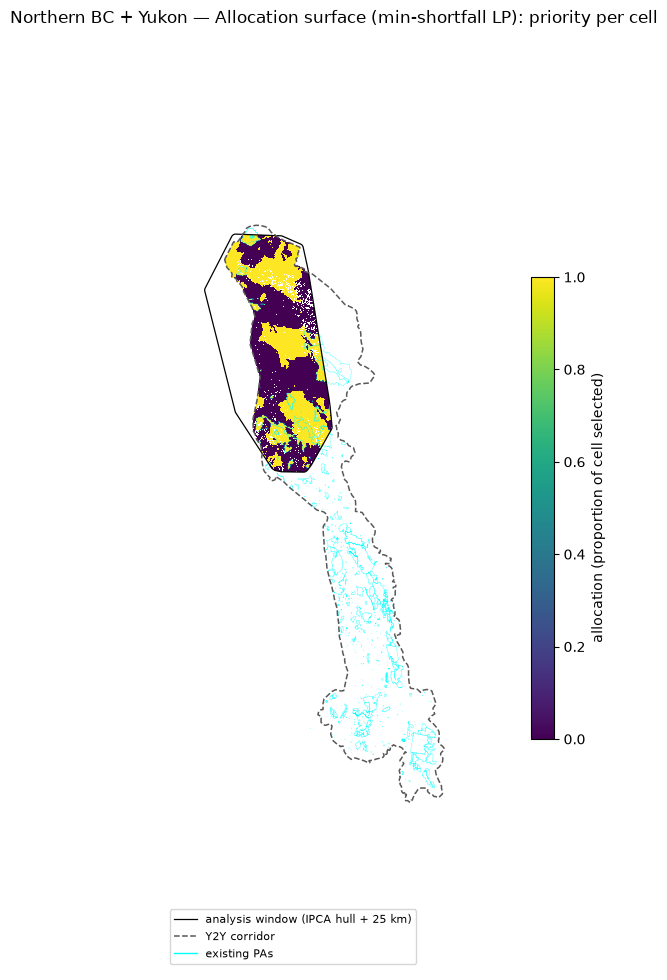

In [3]:
# ---- Allocation surface / selection-frequency map ----
rc.allocation_map(A)

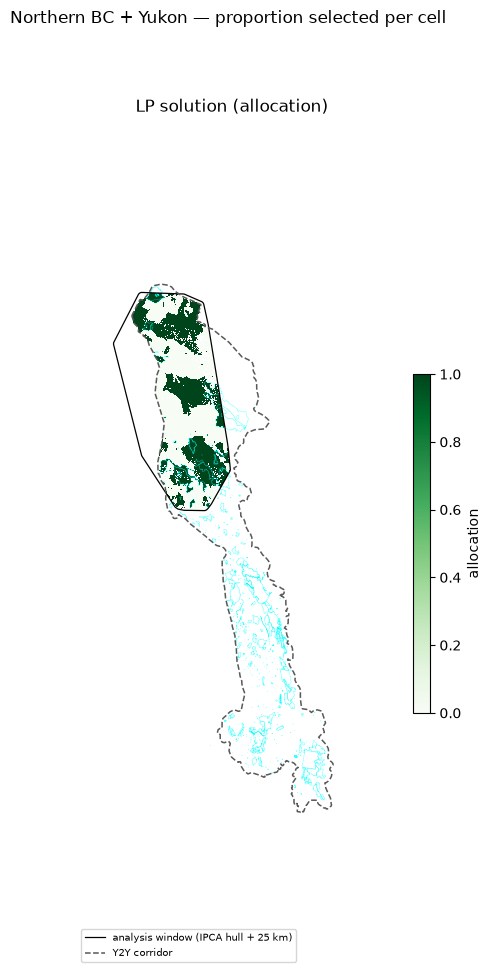

In [4]:
# ---- Solution map(s) ----
rc.solution_maps(A)

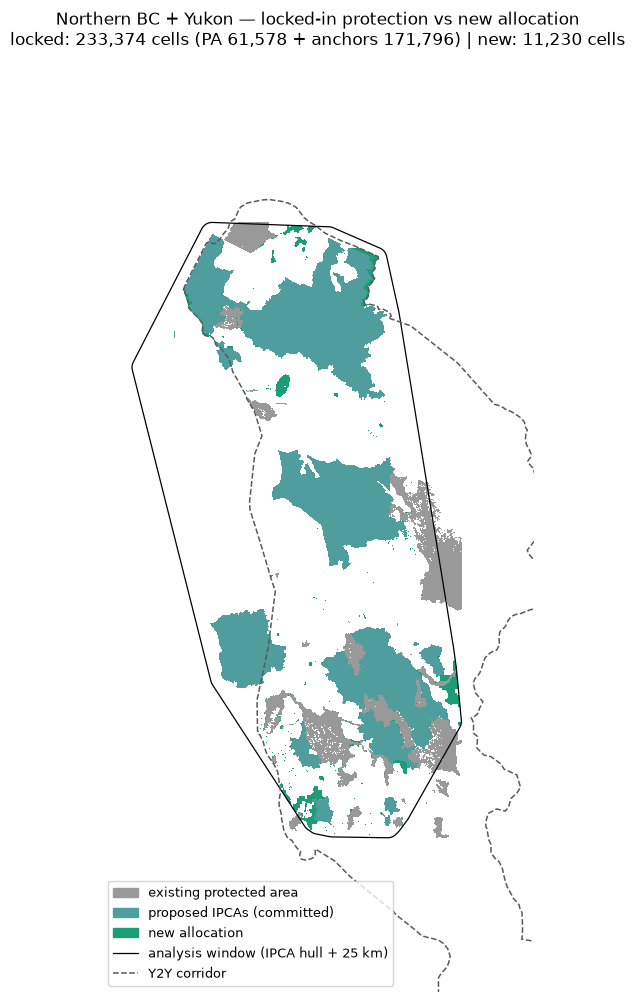

In [5]:
# ---- Existing protection vs new allocation ----
rc.existing_vs_new(A)

In [6]:
# ---- Trade-off table + headline stats ----
rc.tradeoff(A)

Per-solution summary:
alternative  n_selected  pct_region  n_added_beyond_pa
     alt_01   207425.12          43              11230

window planning units : 482,384
area budget (cells)   : 207,425 (43%)
locked-in             : 196,195 (40.7% of window)
area selected         : 43.0% of window


## Candidate areas vs the existing-protection benchmark

`build_stacks` loads the feature stacks, computes **full-Y2Y** region totals (so contribution / efficiency stay “% of Y2Y”), and profiles: the **NEW candidate areas** (connected blocks of new allocation) and the analysis' **benchmark** block (y2y: featured parks + Ross River; north_bc: the 4 IPCA anchors; ab_foothills: the existing in-window PAs). Each area gets three star-plot views + the consequences tables. Figures/CSVs → the run's folder.

**Naming & layout:** the new candidate areas are numbered **Option 1–N** in the order they are selected (the same numbers annotate `rc.new_map`); benchmark / manual areas keep their real names. The consequences tables split their columns into two groups — *Alternatives (new options)* vs *Established Protected/Priority Areas* — and every value prints to at least **2 significant figures** (small cells gain decimals rather than rounding to `0.0`).

In [7]:
# ---- Build stacks + profile NEW clusters + benchmark block (+ manual area) ----
rc.build_stacks(A)

  spread: 6 clusters over lat 56.3-66.6N
new candidate areas   : 688 components, 6 kept (>= 25 cells, spread)
  skip nested benchmark area: Teetł’it Gwinjik (Peel River)
benchmark areas       : 6 profiled [named_vector]
cell size 1.0 km^2 | full-Y2Y PU denom = 1,272,914
shared efficiency scale EFF_RMAX = 0.40 %/1,000 km^2


<results northern_ipcas | iter6_northern_ipcas | 631x1351 | 6 new clusters>

In [8]:
# ---- Corridor check: is the new allocation LINKING anchors, or fresh clumps? ----
# Decisive line = how many connected components the anchors fall in for (locked | new):
# fewer than before = the new allocation is actually connecting them.
rc.corridor_report(A)

Northern BC + Yukon — corridor report

  new allocation      : 11,230 cells (11,230 km²) in 688 components
  singletons          : 432 | median component 1 cells
  attached to locked  : 7,716 cells (69%)  ->  31% DETACHED (connects nothing)
  edges per new cell  : 0.68   (0 = solid blob, ~4 = scattered pixels)

  anchors span 13 connected component(s) of `locked` alone
           -> 11 component(s) once the new allocation is added   [corridors ARE joining anchors]


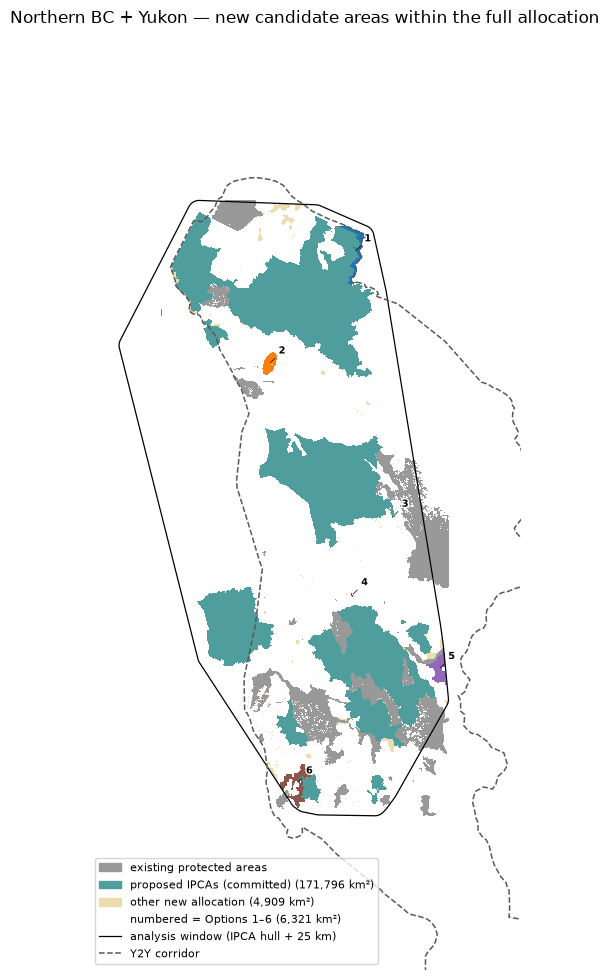

In [9]:
# ---- New candidate areas: map (colored, numbered) within the full allocation ----
rc.new_map(A)

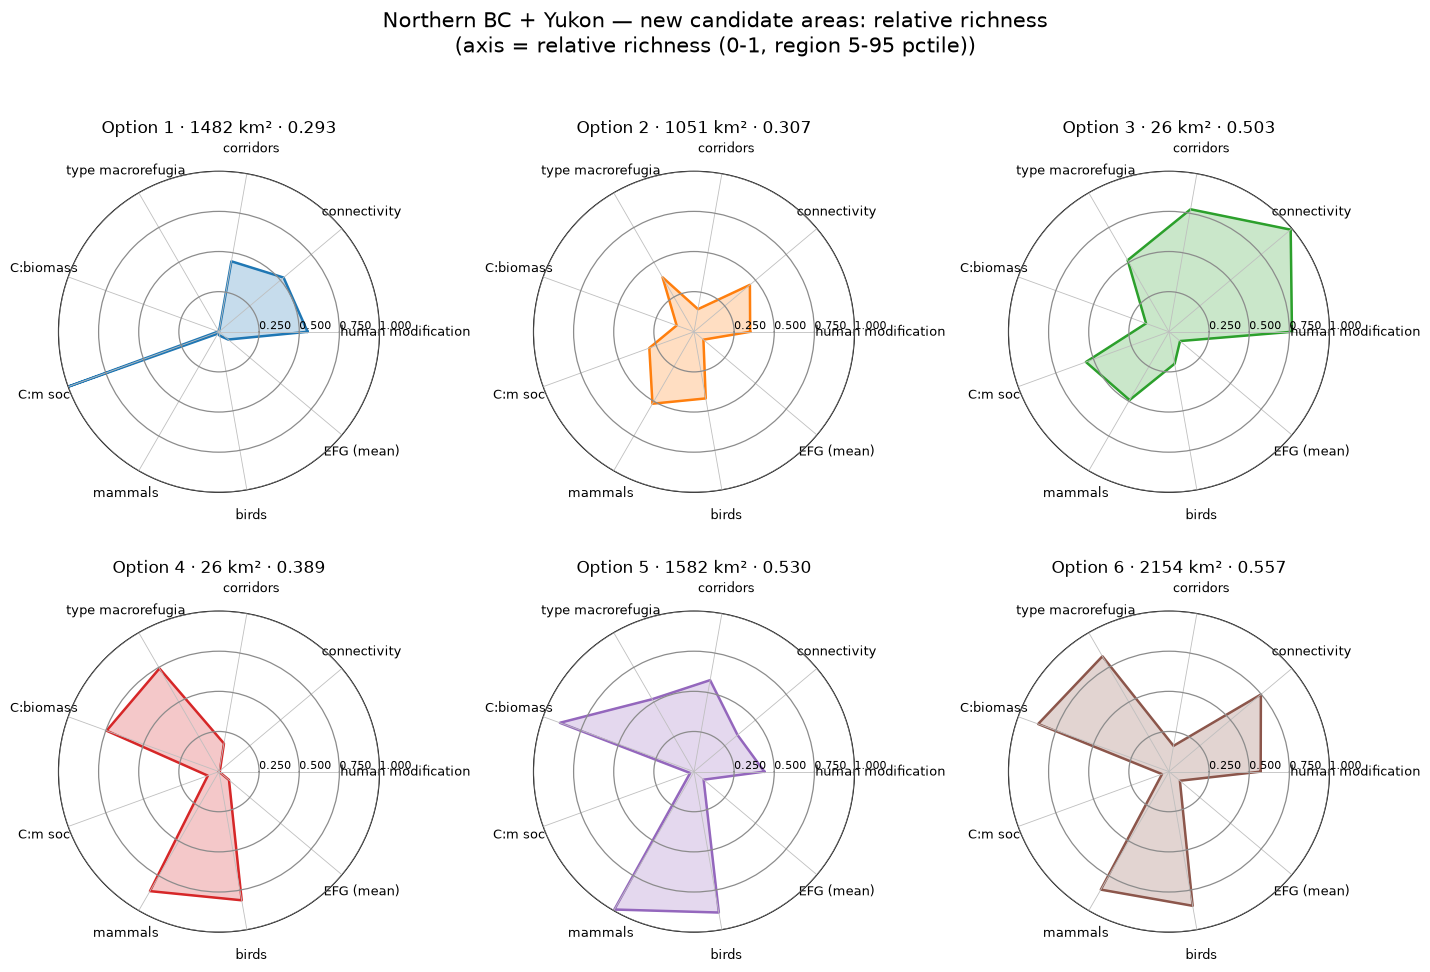

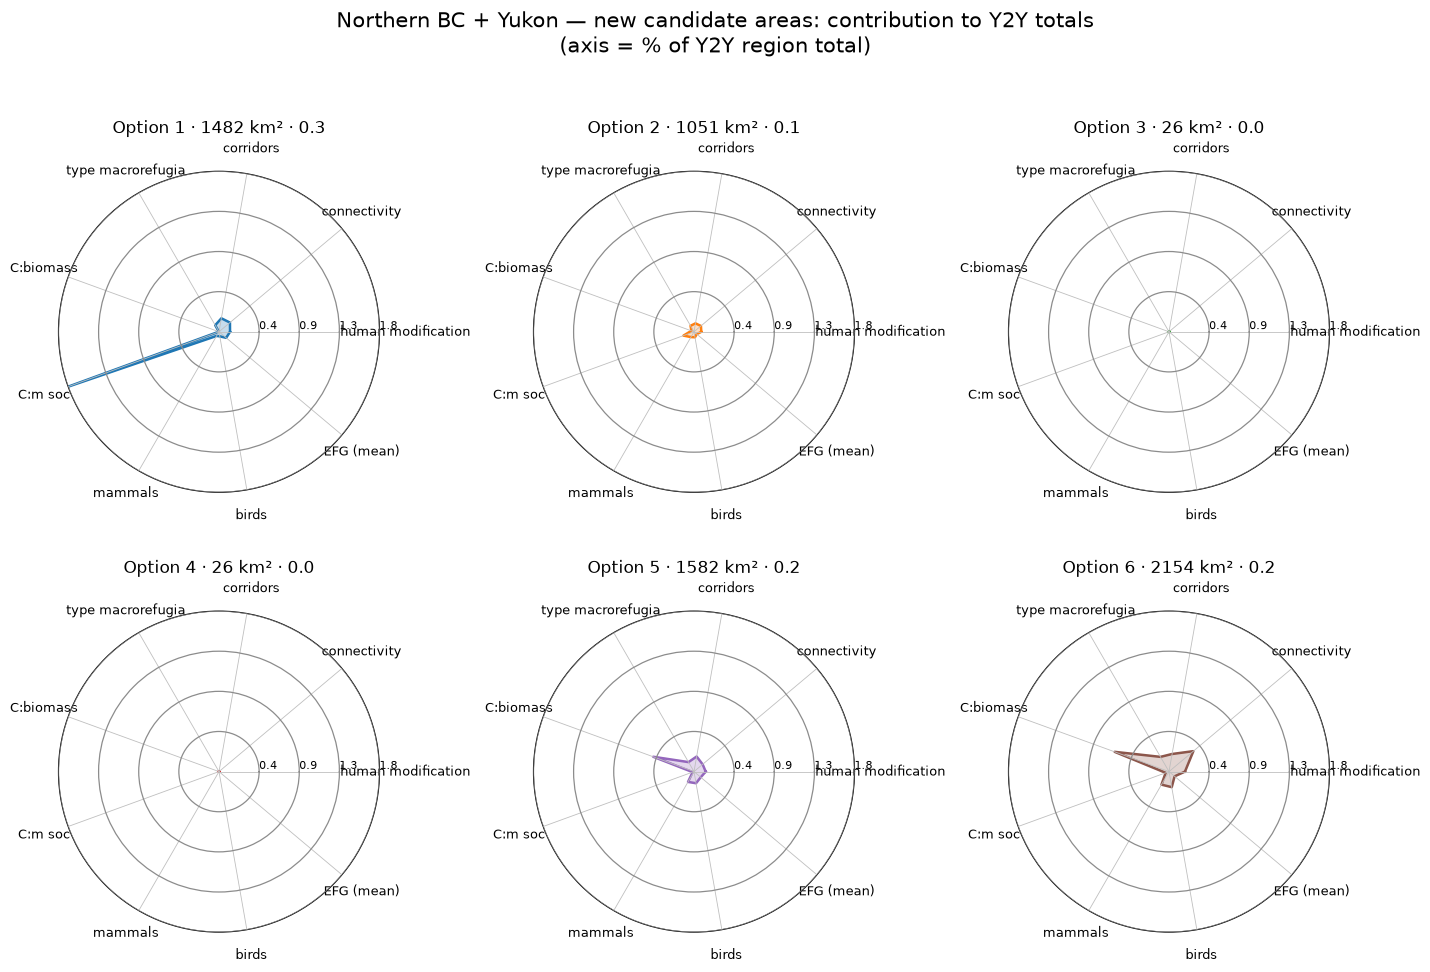

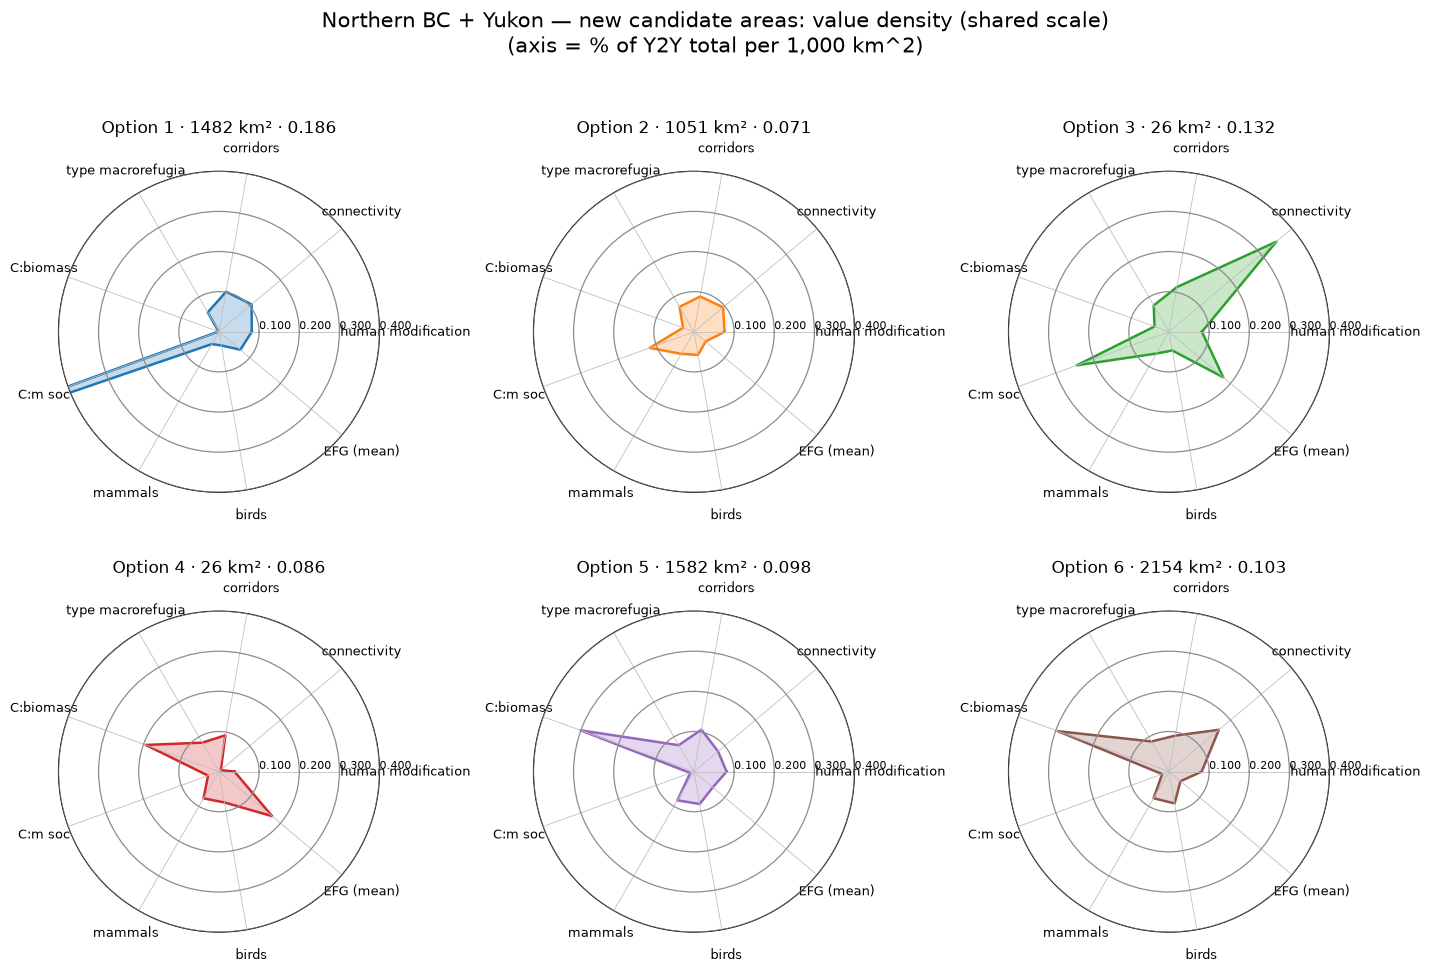

In [10]:
# ---- New candidate areas: 3 star-plot views (richness / contribution / efficiency) ----
rc.new_stars(A)

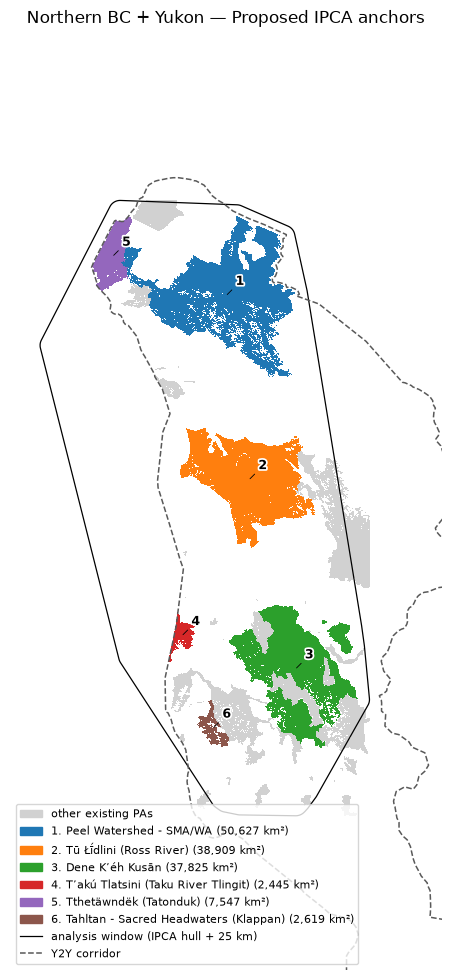

In [11]:
# ---- Benchmark areas: map ----
rc.bench_map(A)

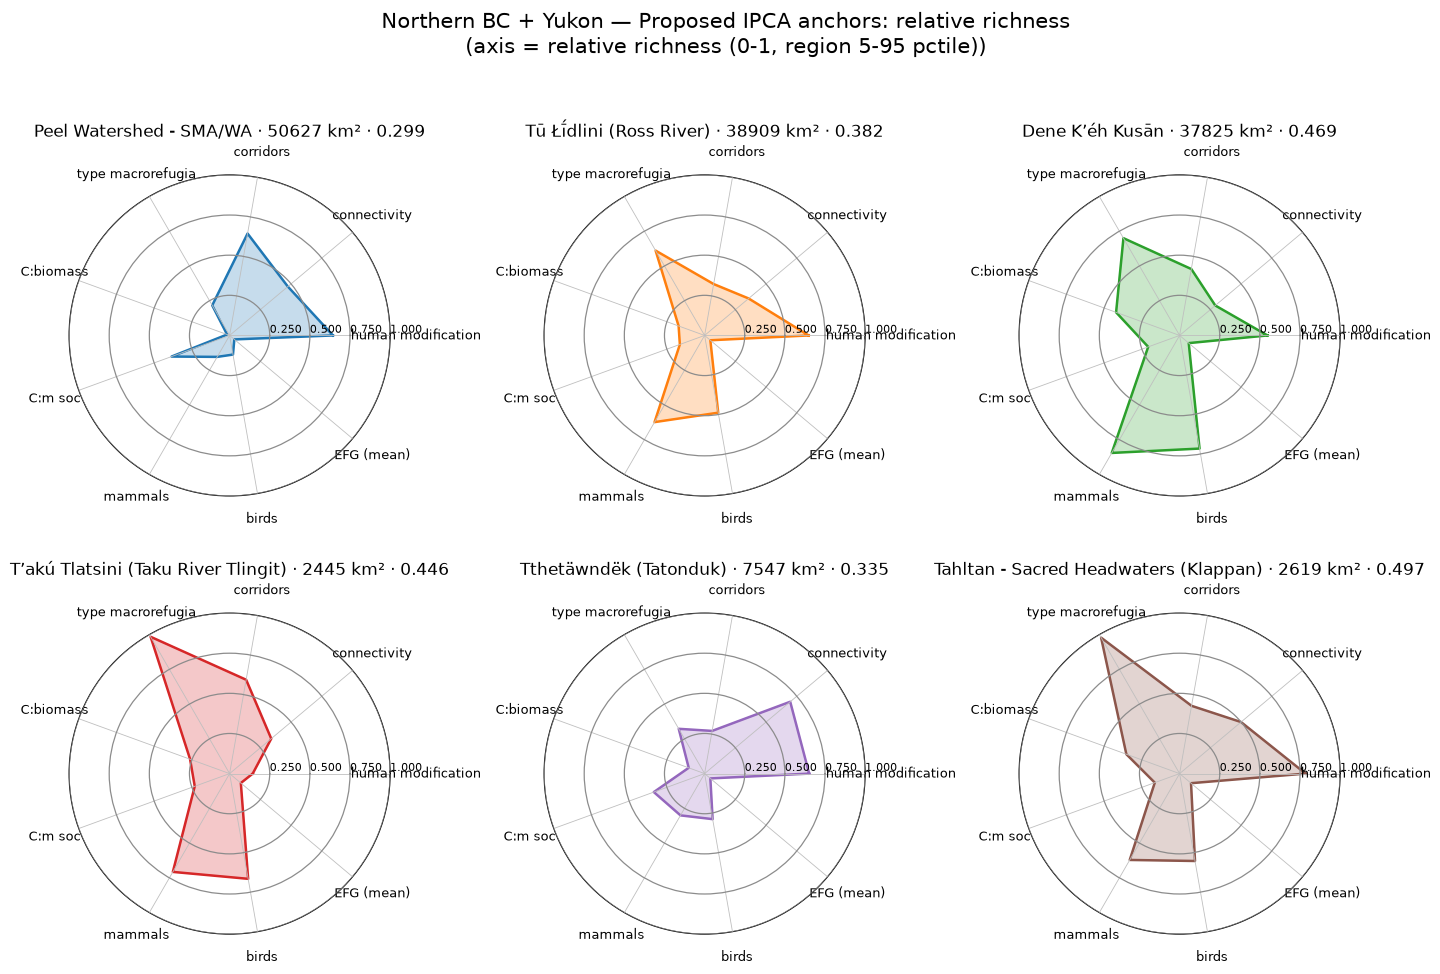

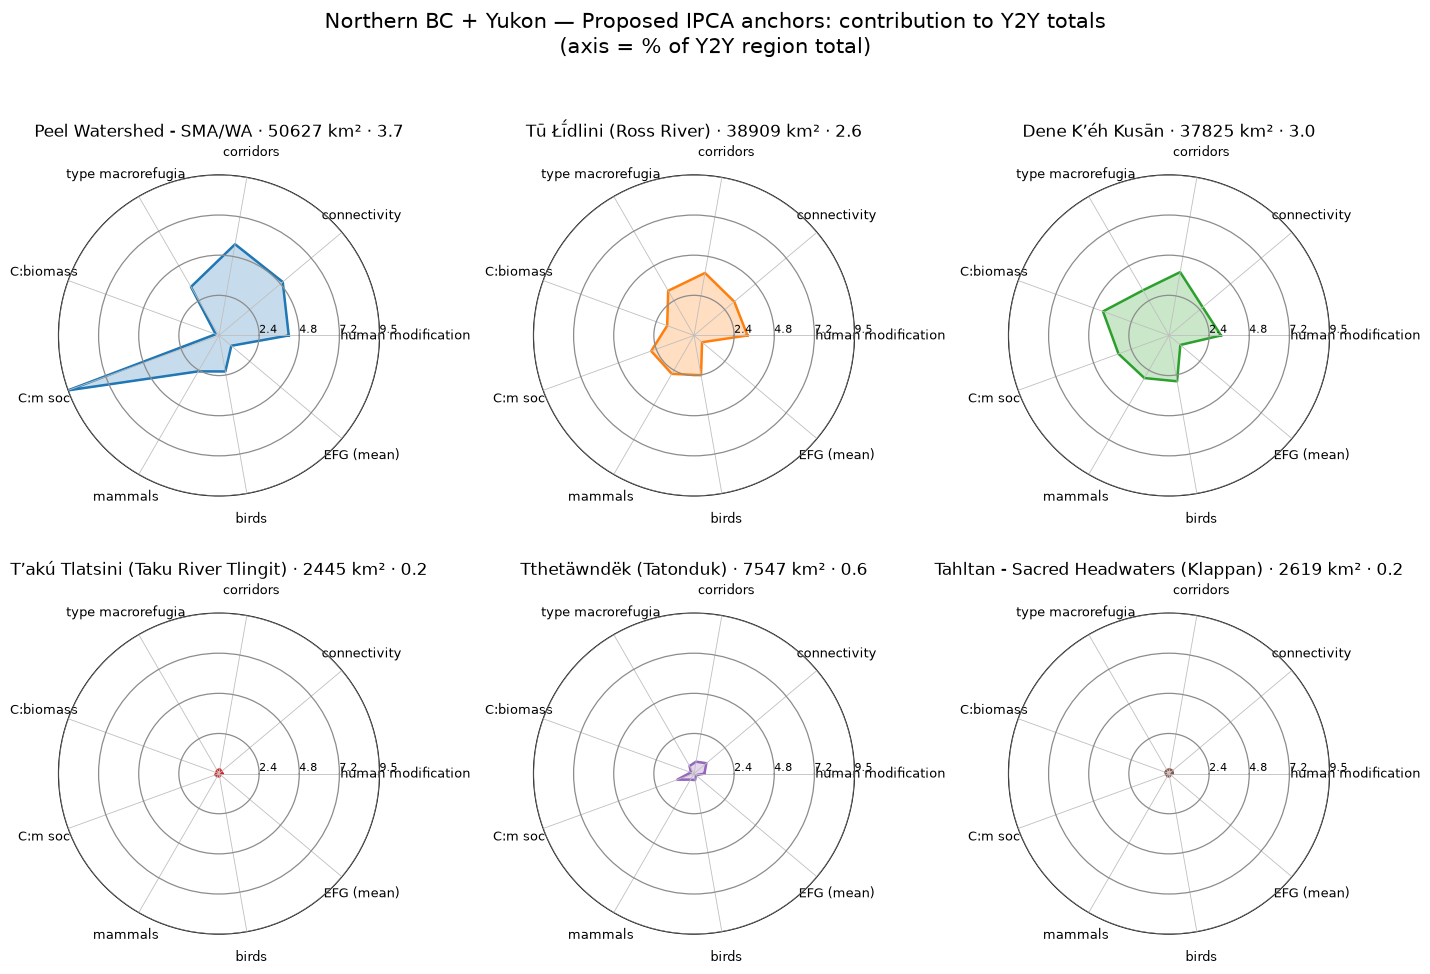

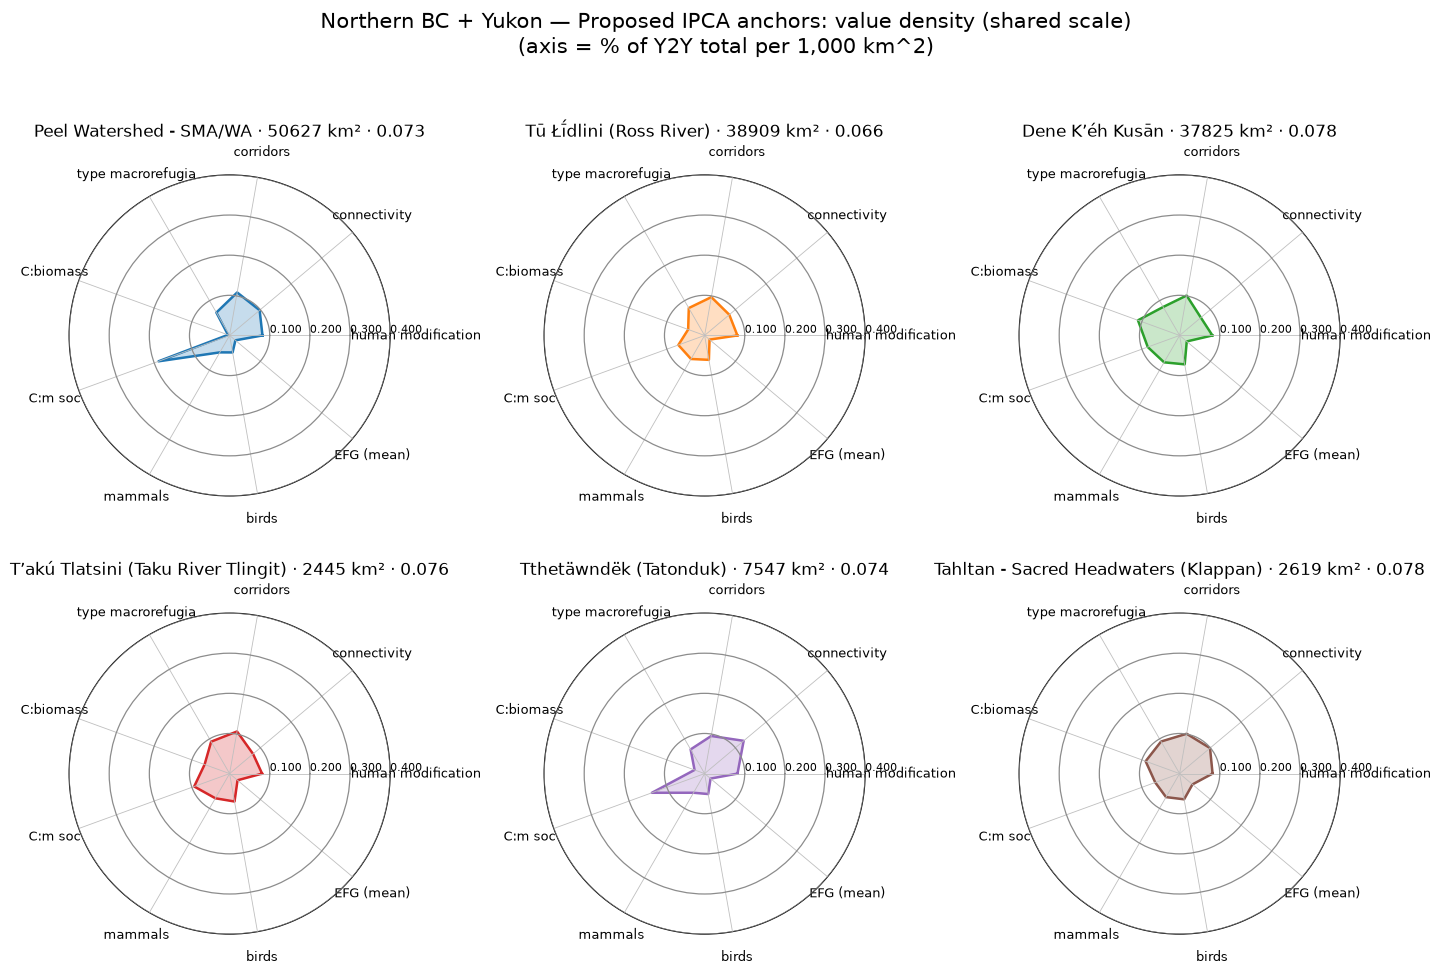

In [12]:
# ---- Benchmark areas: 3 star-plot views ----
rc.bench_stars(A)

In [13]:
# ---- Manual area (Ross River for y2y; no-op for the sub-regions) ----
rc.manual_block(A)

no manual area for this analysis


In [14]:
# ---- Consequences: transposed decision matrices (contribution / efficiency / raw) ----
rc.consequences(A)

CONTRIBUTION (% of Y2Y total):
  Contribution = area's share of the Y2Y region-wide total per input (%). Rows: 2 area metrics + 9 inputs; columns: areas.
                       Alternatives (new options)                                              Established Protected/Priority Areas                                                                                                                                          
                                         Option 1 Option 2 Option 3 Option 4 Option 5 Option 6              Peel Watershed - SMA/WA Tū Łī́dlini (Ross River) Dene Kʼéh Kusān T’akú Tlatsini (Taku River Tlingit) Tthetäwndëk (Tatonduk) Tahltan - Sacred Headwaters (Klappan)
area (km^2)                                 1,482    1,051       26       26    1,582    2,154                               50,627                   38,909          37,825                               2,445                  7,547                                 2,619
area (% of Y2Y)                     

(                                                   Alternatives (new options)                                                  Established Protected/Priority Areas                                                                                                      \
                                                                      Option 1  Option 2 Option 3  Option 4  Option 5  Option 6              Peel Watershed - SMA/WA Tū Łī́dlini (Ross River) Dene Kʼéh Kusān T’akú Tlatsini (Taku River Tlingit) Tthetäwndëk (Tatonduk)   
 Contribution = area's share of the Y2Y region-w...                                                                                                                                                                                                                        
 area (km^2)                                                         1482.0000  1051.000  26.0000  26.00000  1582.000  2154.000                             50627.00                 38909.00       

In [15]:
# ---- Plain-language strongest / weakest summary per area ----
rc.plain_language(A)

Northern BC + Yukon — per-area strongest / weakest inputs (by relative richness):

  [Alternatives (new options)]
  Option 1               strongest: Carbon: mineral soil, Intactness, Connectivity   |   weakest: Climate refugia, Carbon: biomass, Mammal richness
  Option 2               strongest: Mammal richness, Connectivity, Bird richness   |   weakest: Ecosystem groups (EFG), Carbon: biomass, Climate corridors
  Option 3               strongest: Connectivity, Climate corridors, Intactness   |   weakest: Ecosystem groups (EFG), Carbon: biomass, Bird richness
  Option 4               strongest: Mammal richness, Bird richness, Carbon: biomass   |   weakest: Intactness, Connectivity, Carbon: mineral soil
  Option 5               strongest: Mammal richness, Bird richness, Carbon: biomass   |   weakest: Carbon: mineral soil, Ecosystem groups (EFG), Connectivity
  Option 6               strongest: Carbon: biomass, Bird richness, Mammal richness   |   weakest: Carbon: mineral soil, Ecosyste

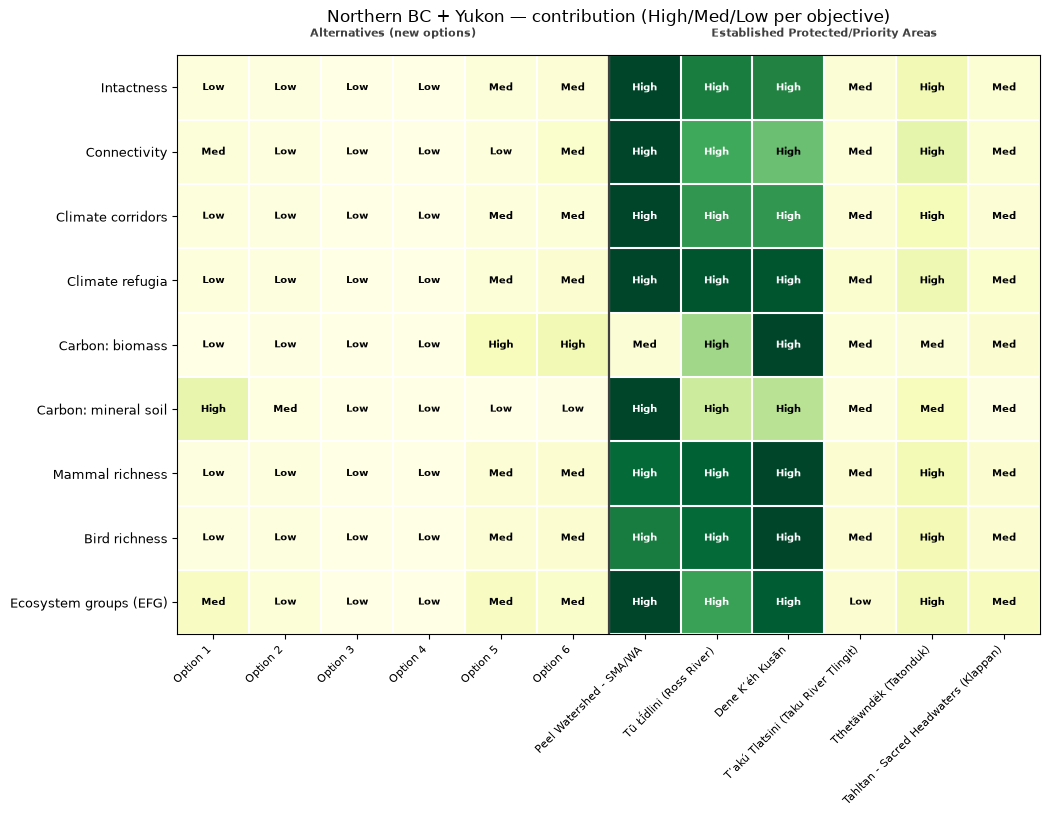

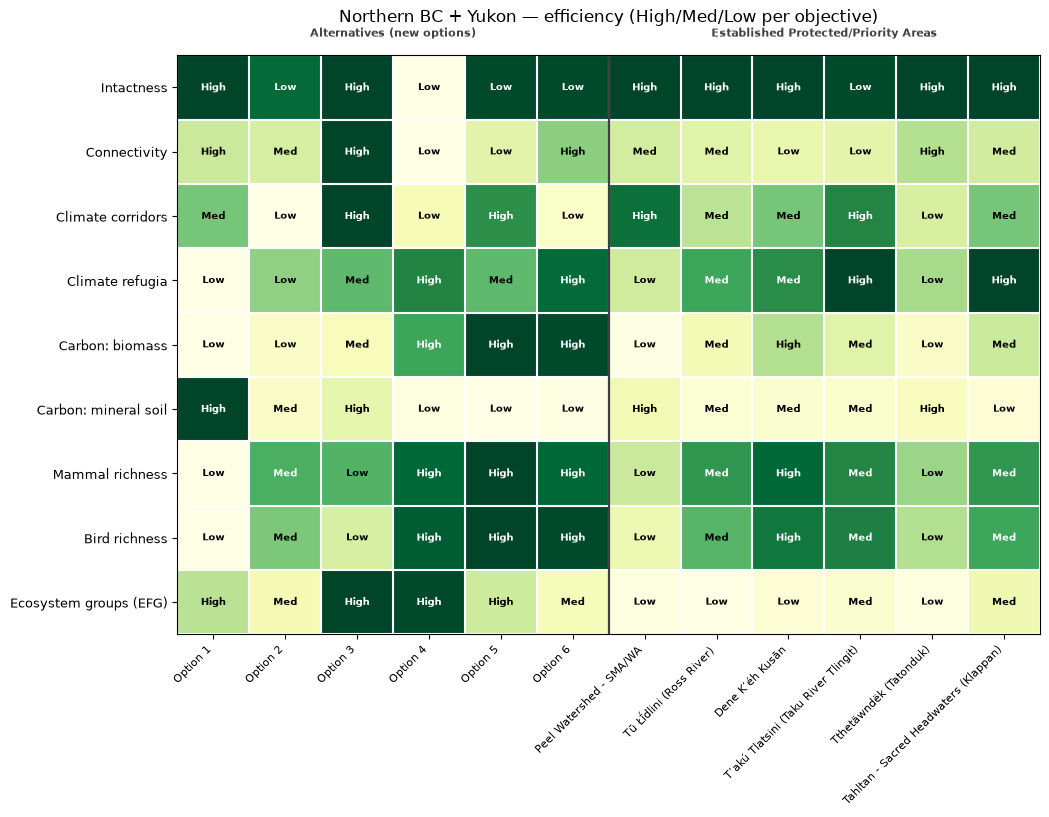

In [16]:
# ---- Colors-only High/Med/Low heatmaps (workshop / accessibility) ----
rc.heatmaps(A)